Name: Dev Patel 

Course: DS4400 Data Mining and Machine Learning 1

Prof: Silvio Amir

University: Northeastern University

Problem 3: Comparing Classifiers

Train Logistic Regression, LDA, and kNN on SPAMBASE and compare.

1. Use cross-validation to select k for kNN.
2. Report accuracy, error, precision, recall for all 3 classifiers on train and test.
3. ROC curve for logistic regression using a package.
4. ROC curve without a package for logistic regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

In [2]:
# Load SPAMBASE dataset
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
    'spam'
]

df = pd.read_csv('spambase.data', header=None, names=col_names)
X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (3450, 57), X_test: (1151, 57)


### Part 1: Cross-Validation for kNN

In [3]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv_rows = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    avg_acc = scores.mean()
    avg_err = 1 - avg_acc
    
    # Fit on full train to get precision/recall on CV
    prec_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='precision')
    rec_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='recall')
    
    cv_rows.append({
        'k': k,
        'Accuracy': round(avg_acc, 4),
        'Error': round(avg_err, 4),
        'Precision': round(prec_scores.mean(), 4),
        'Recall': round(rec_scores.mean(), 4)
    })

cv_df = pd.DataFrame(cv_rows)
print("kNN Cross-Validation Results:\n")
print(cv_df.to_string(index=False))

best_k = cv_df.loc[cv_df['Error'].idxmin(), 'k']
print(f"\nBest k (lowest CV error): {best_k}")

kNN Cross-Validation Results:

 k  Accuracy  Error  Precision  Recall
 1    0.8052 0.1948     0.7520  0.7429
 3    0.7997 0.2003     0.7486  0.7287
 5    0.7925 0.2075     0.7420  0.7138
 7    0.7870 0.2130     0.7331  0.7093
 9    0.7867 0.2133     0.7317  0.7108
11    0.7832 0.2168     0.7283  0.7040
15    0.7736 0.2264     0.7141  0.6943
21    0.7641 0.2359     0.7052  0.6742

Best k (lowest CV error): 1


### Part 2: Compare All 3 Classifiers

In [4]:
# Train all 3 classifiers
lr = LogisticRegression(max_iter=10000, random_state=42)
lda = LinearDiscriminantAnalysis()
knn = KNeighborsClassifier(n_neighbors=int(best_k))

models = {'Logistic Regression': lr, 'LDA': lda, 'kNN': knn}

comp_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    
    for label, X_eval, y_eval in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        y_pred = model.predict(X_eval)
        acc = accuracy_score(y_eval, y_pred)
        comp_rows.append({
            'Model': name,
            'Set': label,
            'Accuracy': round(acc, 4),
            'Error': round(1 - acc, 4),
            'Precision': round(precision_score(y_eval, y_pred, zero_division=0), 4),
            'Recall': round(recall_score(y_eval, y_pred, zero_division=0), 4)
        })

comp_df = pd.DataFrame(comp_rows)
print("Classifier Comparison:\n")
comp_df

Classifier Comparison:



,Model,Set,Accuracy,Error,Precision,Recall
0,Logistic Regression,Train,0.9296,0.0704,0.9267,0.8886
1,Logistic Regression,Test,0.9305,0.0695,0.9438,0.8842
2,LDA,Train,0.8867,0.1133,0.9157,0.7795
3,LDA,Test,0.8853,0.1147,0.9298,0.7811
4,kNN,Train,0.9994,0.0006,0.9993,0.9993
5,kNN,Test,0.7993,0.2007,0.7574,0.7558


**Observations:**

- **Logistic Regression** provides a good balance of accuracy, precision, and recall. It is a linear model that works well when features are approximately linearly separable.

- **LDA** performs comparably to logistic regression since both are linear classifiers. LDA assumes normally distributed features with equal covariance, which may not hold perfectly for the SPAMBASE data.

- **kNN** is a non-parametric model. Its performance depends heavily on the choice of k and the distance metric. It may overfit on training data (high train accuracy) but generalize less well than the linear models.

- The model with the highest test accuracy is generally the best performer. The gap between train and test accuracy indicates how much each model overfits.

### Part 3: ROC Curve with Package

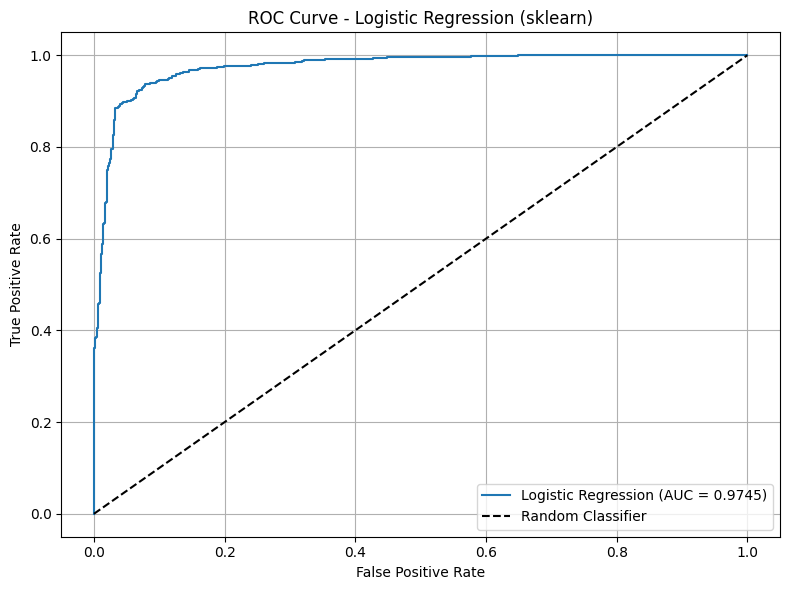

AUC: 0.9745


In [5]:
y_proba = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (sklearn)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")

### Part 4: ROC Curve Without Package

Manual ROC Points:

 Threshold      FPR      TPR
       0.0 1.000000 1.000000
       0.1 0.310651 0.985263
       0.2 0.164201 0.972632
       0.3 0.096154 0.943158
       0.4 0.066568 0.922105
       0.5 0.036982 0.884211
       0.6 0.031065 0.827368
       0.7 0.026627 0.789474
       0.8 0.020710 0.713684
       0.9 0.011834 0.589474
       1.0 0.000000 0.000000


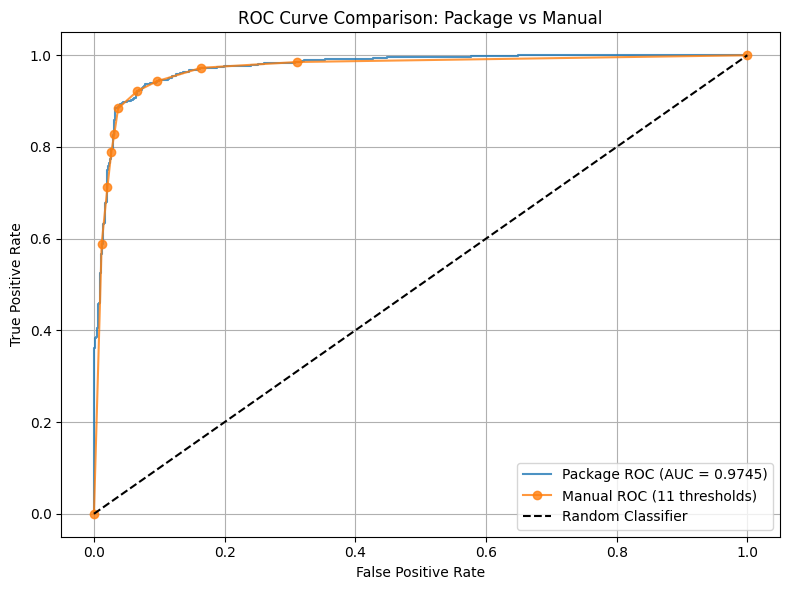

In [6]:
thresholds_manual = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

y_proba = lr.predict_proba(X_test)[:, 1]
y_true = y_test.values

fpr_manual = []
tpr_manual = []

for t in thresholds_manual:
    y_pred_t = (y_proba >= t).astype(int)
    
    # True positives, false positives, etc.
    tp = np.sum((y_pred_t == 1) & (y_true == 1))
    fp = np.sum((y_pred_t == 1) & (y_true == 0))
    tn = np.sum((y_pred_t == 0) & (y_true == 0))
    fn = np.sum((y_pred_t == 0) & (y_true == 1))
    
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    tpr_manual.append(tpr_val)
    fpr_manual.append(fpr_val)

roc_manual_df = pd.DataFrame({'Threshold': thresholds_manual, 'FPR': fpr_manual, 'TPR': tpr_manual})
print("Manual ROC Points:\n")
print(roc_manual_df.to_string(index=False))

# Plot both ROC curves
fpr_pkg, tpr_pkg, _ = roc_curve(y_test, y_proba)
roc_auc_pkg = auc(fpr_pkg, tpr_pkg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pkg, tpr_pkg, label=f'Package ROC (AUC = {roc_auc_pkg:.4f})', alpha=0.8)
plt.plot(fpr_manual, tpr_manual, 'o-', label='Manual ROC (11 thresholds)', alpha=0.8)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Package vs Manual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparison of ROC Curves:**

- **Package ROC curve** is smooth because `roc_curve` from sklearn uses every unique predicted probability as a threshold, resulting in many points that trace out a detailed curve.

- **Manual ROC curve** uses only 11 evenly spaced thresholds (0 to 1 in steps of 0.1), so it is a coarse approximation with straight-line segments between points. It captures the general shape but misses fine details.

- **Differences:** The manual curve appears more angular and less smooth. It may underestimate the true AUC because it does not capture the curve in regions between the 11 threshold values.

- **To make them more similar:** Use more threshold values (e.g., steps of 0.01 or even 0.001) to increase the resolution of the manual ROC curve. Using all unique predicted probabilities as thresholds would make the manual curve identical to the package curve.